# Beta, stratification, and Burger-number hypotheses

This notebook asks whether the equatorward increase in measured `TiltDis` is better described by beta alone, stratification, `N2/f²`, a transparent deformation-radius/Burger proxy, or background shear. Beta is inseparable from latitude, so spatial robustness and comparisons among competing predictors are central.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd()
ANALYSIS_ROOT = HERE.parent
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(ANALYSIS_ROOT / "beta_effect_background_flow") not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT / "beta_effect_background_flow"))

import seacofs_tilt_tools as tilt
import mechanism_tools as mech

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = mech.require_tilt_measurements(df)
print(f"Rows: {len(df):,}; measured tilts: {df.TiltDis.notna().sum():,}; eddies: {df.Eddy.nunique():,}")


Rows: 127,426; measured tilts: 105,621; eddies: 2,982


In [17]:
N2_CACHE = Path("/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/tilt_mechanisms/n2_eddy_day_v3_core.parquet")
n2 = pd.read_parquet(N2_CACHE)
data = mech.merge_one_to_one_or_many_to_one(df, n2)
for depth in (200, 500):
    data[f"N2_{depth}m_s2"] = data[f"N2_{depth}m_core_s2"]
data = tilt.add_pv_gradient_terms(data, grid)
data = mech.add_stratification_proxies(data)
data = mech.add_tilt_components(data)
print('AE')
data[data.Cyc=='AE'][["TiltDis", "beta", "N2_500m_s2", "N2_over_f2_500m", "Bu_proxy_500m"]].describe()

AE


,TiltDis,beta,N2_500m_s2,N2_over_f2_500m,Bu_proxy_500m
count,53607.000000,6.495000e+04,64952.000000,64952.000000,64952.000000
mean,26.080512,-1.909077e-11,0.000073,11385.121407,0.071533
std,22.617269,7.920902e-13,0.000014,3931.200206,0.076999
min,0.010263,-2.076522e-11,0.000045,5331.661118,0.003315
25%,10.490095,-1.979213e-11,0.000062,8340.525204,0.025340
50%,19.609894,-1.897062e-11,0.000072,10593.546010,0.047827
75%,34.752937,-1.840303e-11,0.000083,13697.238784,0.088765
max,266.951190,-1.755648e-11,0.000135,29764.309135,1.225211


In [18]:
print('CE')
data[data.Cyc=='CE'][["TiltDis", "beta", "N2_500m_s2", "N2_over_f2_500m", "Bu_proxy_500m"]].describe()

CE


,TiltDis,beta,N2_500m_s2,N2_over_f2_500m,Bu_proxy_500m
count,52014.000000,6.247400e+04,62474.000000,62474.000000,62474.000000
mean,21.584768,-1.926012e-11,0.000079,12810.709228,0.096487
std,18.963101,8.227682e-13,0.000017,4831.119348,0.104930
min,0.010924,-2.082975e-11,0.000047,5373.408603,0.004874
25%,8.708036,-2.001376e-11,0.000066,9057.900551,0.035768
50%,16.008249,-1.919284e-11,0.000077,11868.619209,0.063309
75%,28.298188,-1.853122e-11,0.000089,15699.973037,0.118207
max,202.385991,-1.758943e-11,0.000323,65465.079001,3.514835


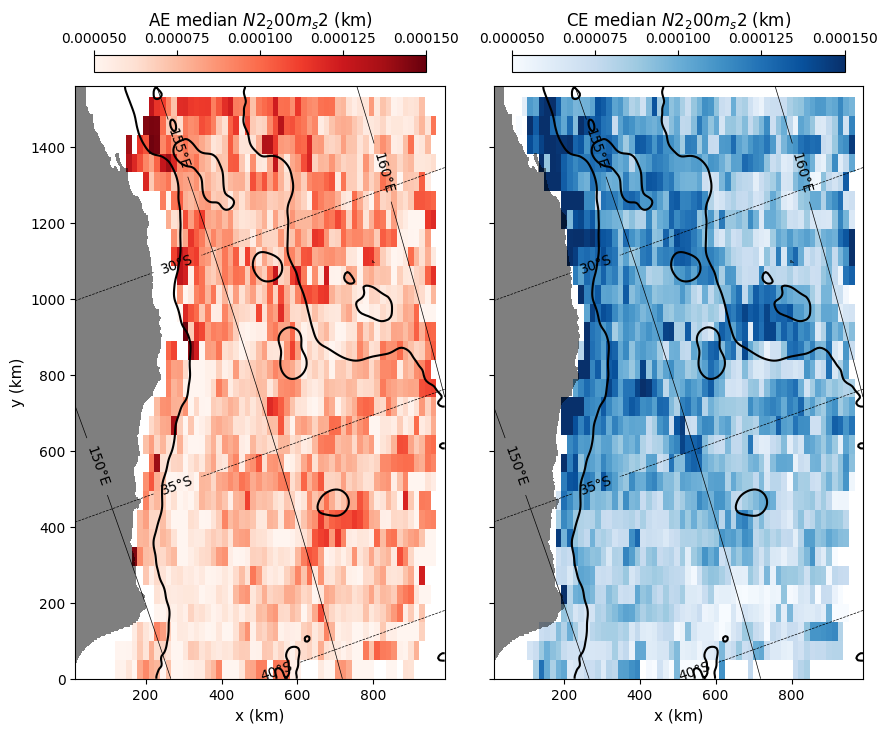

In [32]:
fig, axs = tilt.plot_binned_median_map(data.copy(), grid, 
                                       metric='N2_200m_s2', vmin=0.00005, vmax=.00015)

In [3]:
predictors = ["beta", "N2_200m_s2", "N2_500m_s2", "N2_over_f2_200m",
              "N2_over_f2_500m", "Rd_proxy_500m_km", "Bu_proxy_500m", "Rc", "h"]
eddy = data.groupby(["Cyc", "Eddy"], as_index=False)[["TiltDis", *predictors]].median()
rows = []
from scipy.stats import spearmanr
for cyc, part in eddy.groupby("Cyc"):
    for predictor in predictors:
        use = part[[predictor, "TiltDis"]].dropna()
        rho, p = spearmanr(use[predictor], use["TiltDis"])
        rows.append({"Cyc": cyc, "predictor": predictor, "eddies": len(use), "rho": rho, "p": p})
display(pd.DataFrame(rows).sort_values(["Cyc", "rho"], ascending=[True, False]))


,Cyc,predictor,eddies,rho,p
5,AE,Rd_proxy_500m_km,1422,0.391006,3.720643e-53
4,AE,N2_over_f2_500m,1422,0.391006,3.721164e-53
3,AE,N2_over_f2_200m,1422,0.307374,1.710848e-32
2,AE,N2_500m_s2,1422,0.271705,1.739353e-25
6,AE,Bu_proxy_500m,1422,0.194918,1.216308e-13
1,AE,N2_200m_s2,1422,0.165537,3.381726e-10
7,AE,Rc,1422,-0.038845,1.431697e-01
8,AE,h,1422,-0.221517,2.884887e-17
0,AE,beta,1422,-0.378848,9.387163e-50
13,CE,N2_over_f2_500m,1531,0.345880,2.911232e-44


In [4]:
# Compare predeclared clustered models; coefficients are standardised for scale comparability.
import statsmodels.formula.api as smf

model_sets = {
    "structure_environment": ["Rc", "h"],
    "plus_beta": ["Rc", "h", "beta"],
    "plus_N2": ["Rc", "h", "beta", "N2_500m_s2"],
    "N2_over_f2": ["Rc", "h", "N2_over_f2_500m"],
    "Burger_proxy": ["Rc", "h", "Bu_proxy_500m"],
}
fits, comparison = {}, []
for cyc, part in data.groupby("Cyc"):
    for name, cols in model_sets.items():
        use = part[["Eddy", "TiltDis", *cols]].dropna().copy()
        for col in cols:
            use[f"z_{col}"] = (use[col] - use[col].mean()) / use[col].std()
        fit = smf.gee("np.log1p(TiltDis) ~ " + " + ".join(f"z_{c}" for c in cols),
                      groups="Eddy", data=use).fit()
        fits[(cyc, name)] = fit
        qic = fit.qic()[0] if callable(getattr(fit, "qic", None)) else np.nan
        comparison.append({"Cyc": cyc, "model": name, "rows": len(use),
                           "eddies": use.Eddy.nunique(), "QIC": qic})
display(pd.DataFrame(comparison))


/home/z5297792/myenv310/lib/python3.10/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "
/home/z5297792/myenv310/lib/python3.10/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "
/home/z5297792/myenv310/lib/python3.10/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for comparing models
  warnings.warn("QIC values obtained using scale=None are not "
/home/z5297792/myenv310/lib/python3.10/site-packages/statsmodels/genmod/generalized_estimating_equations.py:1934: UserWarning: QIC values obtained using scale=None are not appropriate for compa

,Cyc,model,rows,eddies,QIC
0,AE,structure_environment,53607,1422,53724.893885
1,AE,plus_beta,53607,1422,53746.154277
2,AE,plus_N2,53607,1422,53782.378462
3,AE,N2_over_f2,53607,1422,53747.817926
4,AE,Burger_proxy,53607,1422,53748.643179
5,CE,structure_environment,52014,1531,52110.841252
6,CE,plus_beta,52014,1531,52127.900002
7,CE,plus_N2,52014,1531,52149.895121
8,CE,N2_over_f2,52014,1531,52139.050816
9,CE,Burger_proxy,52014,1531,52138.554931


In [5]:
# Spatial sensitivity: repeat within broad latitude and shelf regimes.
data["latitude_band"] = pd.cut(data["lat" if "lat" in data else "yc"], 4)
spatial = (data.groupby(["Cyc", "latitude_band"], observed=True)
           .agg(rows=("TiltDis", "size"), eddies=("Eddy", "nunique"),
                tilt=("TiltDis", "median"), n2=("N2_500m_s2", "median"),
                beta=("beta", "median"), burger=("Bu_proxy_500m", "median")))
display(spatial)


rows  eddies       tilt        n2          beta  \
Cyc latitude_band                                                          
AE  (-40.912, -37.101]  18945     499  14.410548  0.000062 -1.819594e-11   
    (-37.101, -33.305]  22094     569  16.381239  0.000071 -1.886830e-11   
    (-33.305, -29.509]  14574     491  27.542649  0.000077 -1.976628e-11   
    (-29.509, -25.712]   9339     307  31.077719  0.000082 -2.032352e-11   
CE  (-40.912, -37.101]  15086     481  11.388181  0.000065 -1.821356e-11   
    (-37.101, -33.305]  19261     592  12.295903  0.000075 -1.890570e-11   
    (-33.305, -29.509]  15483     545  20.177048  0.000083 -1.980586e-11   
    (-29.509, -25.712]  12644     366  25.441802  0.000088 -2.038718e-11   

                          burger  
Cyc latitude_band                 
AE  (-40.912, -37.101]  0.051284  
    (-37.101, -33.305]  0.034218  
    (-33.305, -29.509]  0.049140  
    (-29.509, -25.712]  0.079713  
CE  (-40.912, -37.101]  0.060074  
    (-37.101, -33.305]  0.049079  
    (-33.305, -29.509]  0.062196  
    (-29.509, -25.712]  0.101662

## Interpretation guardrail

Call the equatorward pattern specifically beta-related only if beta adds information beyond structure, bathymetry, stratification and shear and survives spatial blocking. `Rd_proxy` and `Bu_proxy` are constant-N screening proxies, not solved vertical modes; label them as such in figures and text.
